# Tuning
This notebook shows examples of things that happen with tuning.

## Example 1: Just Intonation vs. Equal Temperament vs. Pythagorean Tuning
This example shows the difference between a justly tuned major triad and an equally-tempered major triad. First, we set up some functions.

In [32]:
import matplotlib.pyplot as plt
import numpy as np

def midicps(midi):
    return 440 * 2 ** ((midi - 69) / 12)

def sinewave(freq, sampling_rate, iphase, dur):
    return np.sin(np.linspace(0, freq * dur * 2 * np.pi, int(sampling_rate * dur)) + iphase)

def saw(freq, sampling_rate, iphase, dur, num_harmonics, recip_pow=1):
    sig = np.sin(np.linspace(0, [freq * i * dur * 2 * np.pi for i in range(1, num_harmonics + 1)], int(sampling_rate * dur), axis=1) + iphase)
    amp_scale = np.array([1/(i ** recip_pow) for i in range(1, num_harmonics+1)]).reshape(-1, 1)
    sig *= amp_scale
    return np.sum(sig, axis=0)

SAMPLE_RATE = 22050

Next, let's plot a major triad on A4 in just intonation. Notice that the graph is perfectly periodic.

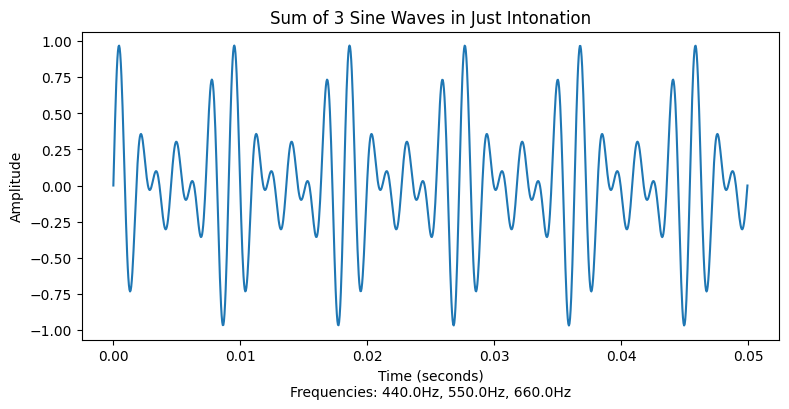

In [2]:
freqs = [440.0, 440 * 5/4, 440 * 3/2]
phase = 0    # range: [0, 2pi)
dur = 0.05  # seconds
sig = np.zeros((int(SAMPLE_RATE * dur)))
for freq in freqs:
    sig += sinewave(freq, SAMPLE_RATE, phase, dur)
sig /= len(freqs)
fig, ax = plt.subplots()
fig.set_size_inches(9, 4)
ax.set_title(f"Sum of {len(freqs)} Sine Waves in Just Intonation")
ax.set_xlabel(f"Time (seconds)\nFrequencies: {"Hz, ".join(map(lambda x: str(round(x, 2)), freqs))}Hz")
ax.set_ylabel("Amplitude")
ax.plot([i / SAMPLE_RATE for i in range(sig.shape[-1])], sig)

Next, we'll plot the equal-tempered version of the triad. Notice that the graph is no longer perfectly periodic, but it is close to being periodic. Equal-tempered frequencies are computed as $$f \cdot 2^{\frac{n}{12}}$$ where $f \in \mathbb{R}$ is the reference frequency and $n \in \mathbb{R}$ is the number of semitones (positive for above, and negative for below the reference frequency). In this case, we have a major third with 4 semitones, so it is $$440 \cdot 2^{\frac{4}{12}} \approx 554.365 \textrm{ Hz}$$ which is $$1200 \log_2\left(\frac{f_{equal}}{f_{just}}\right) \approx 13.686 \textrm{ cents}$$ out of tune from a just $\frac{5}{4}$ major third. It turns out that the fifth is also slightly out of tune, but the tuning error is less: about -1.955 cents. In fact, all equal-tempered intervals except for the octave are slightly out of tune with respect to their justly tuned counterparts.

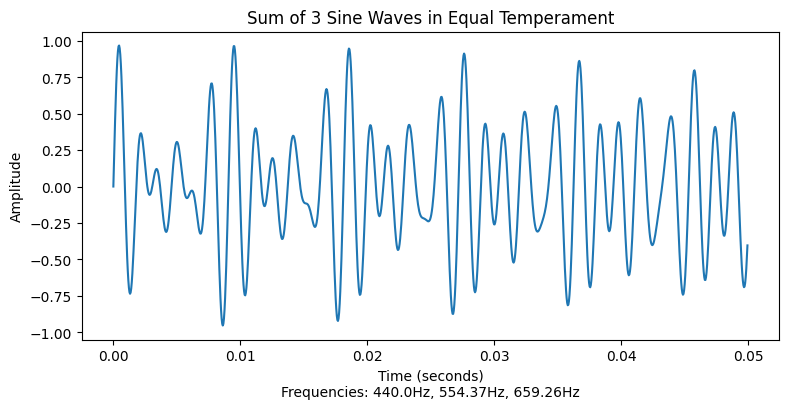

In [3]:
freqs = [midicps(69), midicps(73), midicps(76)]
phase = 0    # range: [0, 2pi)
dur = 0.05  # seconds
sig = np.zeros((int(SAMPLE_RATE * dur)))
for freq in freqs:
    sig += sinewave(freq, SAMPLE_RATE, phase, dur)
sig /= len(freqs)
fig, ax = plt.subplots()
fig.set_size_inches(9, 4)
ax.set_title(f"Sum of {len(freqs)} Sine Waves in Equal Temperament")
ax.set_xlabel(f"Time (seconds)\nFrequencies: {"Hz, ".join(map(lambda x: str(round(x, 2)), freqs))}Hz")
ax.set_ylabel("Amplitude")
ax.plot([i / SAMPLE_RATE for i in range(sig.shape[-1])], sig)

There's an alternative method of tuning that is much older, called Pythagorean tuning. In Pythagorean tuning, the frequencies for all twelve chromatic notes are computed as $$f \left(\frac{3}{2}\right)^n$$ where $f \in \mathbb{R}$ is the reference frequency and $n \in \mathbb{Z}$ represents the number of hops around the circle of fifths (positive for hopping up, and negative for hopping down). This results in a triad with a perfectly tuned fifth, but the major third is even less in tune than the equal-tempered major third. The major third is computed as $$440\frac{\left(\frac{3}{2}\right)^4}{2^2} = 556.875 \textrm{ Hz}$$ because we have to make 4 hops on the circle of fifths to get the major third. We also have to divide by $2^2=4$ to bring it down two octaves to the proper octave. This is $$1200 \log_2\left(\frac{f_{pythagorean}}{f_{just}}\right) \approx 21.506 \textrm{ cents}$$ out of tune from a just $\frac{5}{4}$ major third. You can see on the graph that the tuning is worse here as well.

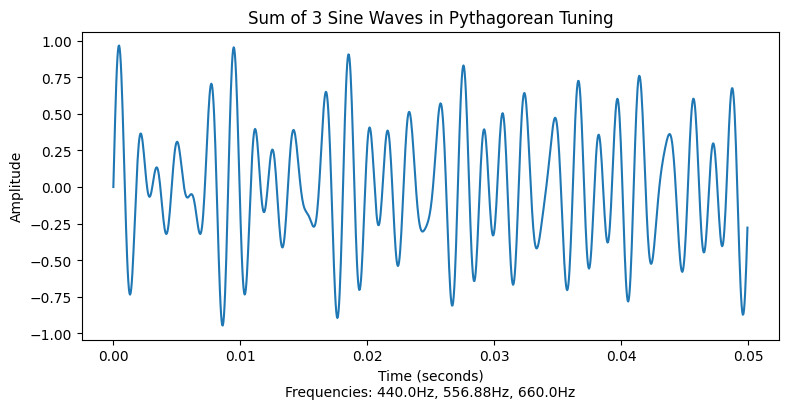

In [5]:
freqs = [440.0, 440.0 * (3/2) ** 4 / 4, 440 * 3/2]
phase = 0    # range: [0, 2pi)
dur = 0.05  # seconds
sig = np.zeros((int(SAMPLE_RATE * dur)))
for freq in freqs:
    sig += sinewave(freq, SAMPLE_RATE, phase, dur)
sig /= len(freqs)
fig, ax = plt.subplots()
fig.set_size_inches(9, 4)
ax.set_title(f"Sum of {len(freqs)} Sine Waves in Pythagorean Tuning")
ax.set_xlabel(f"Time (seconds)\nFrequencies: {"Hz, ".join(map(lambda x: str(round(x, 2)), freqs))}Hz")
ax.set_ylabel("Amplitude")
ax.plot([i / SAMPLE_RATE for i in range(sig.shape[-1])], sig)

Let's play some examples. We'll use a modified sawtooth waveform, because the chords will sound better that way. Playing a triad in close position with only sine waves sounds rather obnoxious. Furthermore, when the triad is tuned in just intonation, the sine waves tend to fuse and we hear a new pitch two octaves below the root of the triad.

Our sawtooth waveform uses lower amplitudes for the higher partials so that it sounds more pleasant.

First the just intonation version. This one sounds very stable.

In [51]:
import pathlib
import soundfile
import IPython
dur=2
sig = np.zeros((int(SAMPLE_RATE * dur)))
freqs=[220, 220*5/4, 220*3/2]
for freq in freqs:
    sig += saw(freq, SAMPLE_RATE, phase, dur, 50, 4)
sig *= 0.1
PATH="data/out_just.wav"
pathlib.Path("data").mkdir(exist_ok=True)
soundfile.write(PATH, sig, SAMPLE_RATE)
IPython.display.Audio(PATH)

And the equal-tempered version. You should be able to hear some subtle beating.

In [52]:
sig = np.zeros((int(SAMPLE_RATE * dur)))
freqs=[midicps(57), midicps(61), midicps(64)]
for freq in freqs:
    sig += saw(freq, SAMPLE_RATE, phase, dur, 50, 4)
sig *= 0.1
PATH="data/out_et.wav"
pathlib.Path("data").mkdir(exist_ok=True)
soundfile.write(PATH, sig, SAMPLE_RATE)
IPython.display.Audio(PATH)

And the Pythagorean version. Here the pulsing is faster because the third is more out of tune.

In [53]:
sig = np.zeros((int(SAMPLE_RATE * dur)))
freqs=[220, 220 * 3 ** 4 / 2 ** 6, 220*3/2]
for freq in freqs:
    sig += saw(freq, SAMPLE_RATE, phase, dur, 50, 4)
sig *= 0.1
PATH="data/out_py.wav"
pathlib.Path("data").mkdir(exist_ok=True)
soundfile.write(PATH, sig, SAMPLE_RATE)
IPython.display.Audio(PATH)

## Example 3: Psychoacoustic Effect of Two Frequencies Close Together

When we have two sine waves that are very close in frequency to each other, we get amplitude modulation if we play them together. For example, consider the frequencies 440 and 480 Hz:

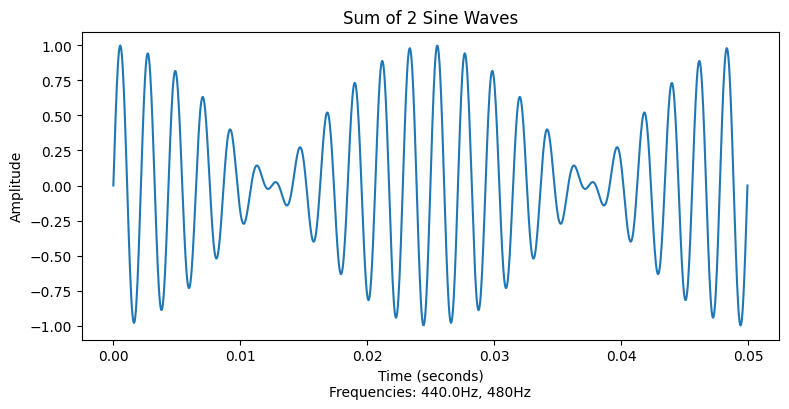

In [4]:
freqs = [440.0, 480]
phase = 0    # range: [0, 2pi)
dur = 0.05  # seconds
sig = np.zeros((int(SAMPLE_RATE * dur)))
for freq in freqs:
    sig += sinewave(freq, SAMPLE_RATE, phase, dur)
sig /= len(freqs)
fig, ax = plt.subplots()
fig.set_size_inches(9, 4)
ax.set_title(f"Sum of {len(freqs)} Sine Waves")
ax.set_xlabel(f"Time (seconds)\nFrequencies: {"Hz, ".join(map(lambda x: str(round(x, 2)), freqs))}Hz")
ax.set_ylabel("Amplitude")
ax.plot([i / SAMPLE_RATE for i in range(sig.shape[-1])], sig)

These frequencies are $$12 \log_2 \left(\frac{480}{440}\right) \approx 1.5 \textrm{ semitones}$$ apart. We can, of course, hear this as two different pitches--this interval is a bit bigger than a minor second. As the frequencies get closer together, these amplitude modulation pulses will get longer and longer (which we can hear as the beats slowing down), and it becomes hard to plot nicely. However, here's an example of 440 and 441 Hz:

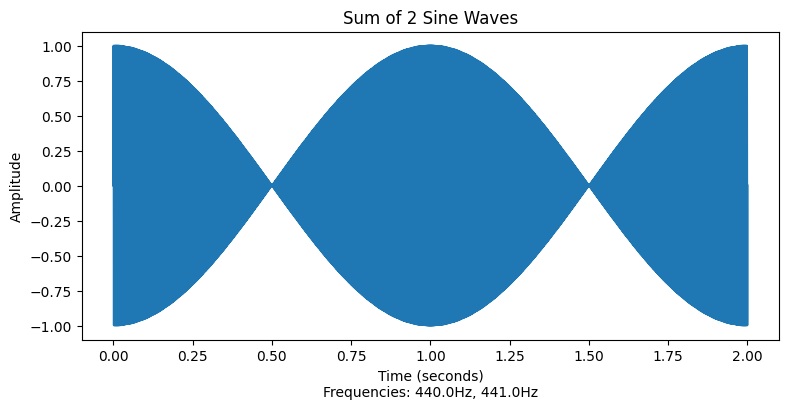

In [37]:
freqs = [440.0, 441.0]
phase = 0    # range: [0, 2pi)
dur = 2  # seconds
sig = np.zeros((int(SAMPLE_RATE * dur)))
for freq in freqs:
    sig += sinewave(freq, SAMPLE_RATE, phase, dur)
sig /= len(freqs)
fig, ax = plt.subplots()
fig.set_size_inches(9, 4)
ax.set_title(f"Sum of {len(freqs)} Sine Waves")
ax.set_xlabel(f"Time (seconds)\nFrequencies: {"Hz, ".join(map(lambda x: str(round(x, 2)), freqs))}Hz")
ax.set_ylabel("Amplitude")
ax.plot([i / SAMPLE_RATE for i in range(sig.shape[-1])], sig)

Here, the beating is so slow that we have to plot much more of the audio to see it. When two notes are so close together, we will perceive them as a single pitch instead of two separate pitches (although we will certainly hear the amplitude modulation). Of course, if we were to perform a FFT on this audio excerpt, it's clear that two frequencies are present:

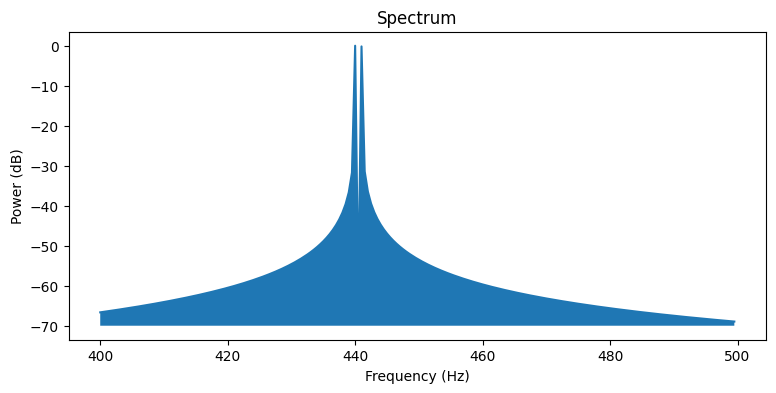

In [38]:
import scipy.fft as fft
pow = np.square(np.abs(fft.rfft(sig)))
freqs = fft.rfftfreq(sig.shape[-1], 1/SAMPLE_RATE)
spec = 10 * np.log10(pow / np.max(np.abs(pow)))
fig, ax = plt.subplots()
fig.set_size_inches(9, 4)
ax.set_title(f"Spectrum")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power (dB)")
ax.plot(freqs[800:1000], spec[800:1000])
ax.fill_between(freqs[800:1000], spec[800:1000], -70)
plt.show()

But our sense of hearing doesn't really work like a Fourier frequency detector for determining pitch. Instead, our model of pitch corresponds more closely to autocorrelation, which tracks the periodicity of the waveform. Let's take a look at that.

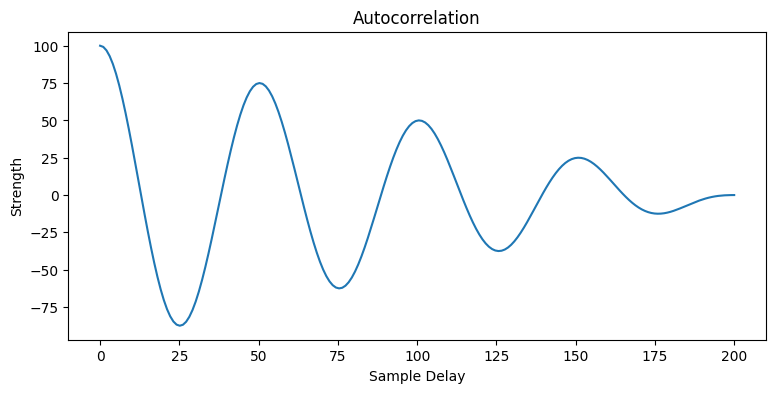

In [39]:
import librosa
ac = librosa.autocorrelate(sig[:200])
fig, ax = plt.subplots()
fig.set_size_inches(9, 4)
ax.set_title(f"Autocorrelation")
ax.set_xlabel("Sample Delay")
ax.set_ylabel("Strength")
ax.plot(np.linspace(0, ac.shape[-1], ac.shape[-1]), ac)
# ax.fill_between(freqs[800:1000], spec[800:1000], -70)
plt.show()

We can inspect the graph and see that approximately every 50 samples, there's a positive autocorrelation peak. This suggests that the period is about 50 samples. We can verify this.

In [40]:
peaks = []
for i in range(1, len(ac) - 1):
    if ac[i-1] < ac[i] > ac[i+1]:
        peaks.append((i, ac[i]))
avg_diff = sum([peaks[i][0] - peaks[i-1][0] for i in range(1, len(peaks))]) / (len(peaks)-1)
print(peaks)

[(50, np.float64(75.06178933092686)), (100, np.float64(50.03669574365864)), (150, np.float64(25.0140339716479))]


It is in fact 50 samples. We can compute the pitch based on the sample rate and the period. Note that the distance between the autocorrelation peaks is quantized to the nearest sample, so there is some error.

In [41]:
SAMPLE_RATE / avg_diff

441.0

So it is about 441 Hz. Notice that unlike the spectrum above, the autocorrelation graph doesn't show us separate peaks here for the different frequencies. This aligns with our sense that the two frequencies are fused.